In [1]:
# 导入必要的库
import numpy as np                          # 数值计算库
from vpsto.vpsto import VPSTO, VPSTOOptions # VPSTO轨迹优化库
from vpsto.obf import OBF                   # 椭球基函数库
import matplotlib.pyplot as plt             # 绘图库
import matplotlib.patches as patches        # matplotlib几何图形补丁

# Jupyter notebook魔法命令，用于自动重新加载模块
%load_ext autoreload
%autoreload 2

In [2]:
# 配置项：是否保存生成的图片
# 设置为True时会将生成的图片保存到本地文件
save_figures = False # set to True to save figures

In [3]:
# 定义2D机械臂类，包含正向运动学计算
class Manipulator():
    def __init__(self):
        # 机械臂链接长度：两段链接长度均为1
        self.l = np.array([1, 1]) # link lengths
        # 关节角度限制：第一关节[0, π]，第二关节[-π, 0]
        self.q_min = np.array([0., -np.pi])    # 关节角度下限
        self.q_max = np.array([np.pi, 0.])     # 关节角度上限

    # 定义机械臂的正向运动学
    def fk(self, q):
        """
        正向运动学函数：根据关节角度计算机械臂各关节的笛卡尔坐标位置
        参数：
        q: 2x1数组，包含两个关节的角度
        返回：3x2数组，包含基座、第一关节和末端执行器的二维位置
        """
        x0 = np.zeros(2)  # 基座位置（原点）
        # 第一关节位置：基座 + 第一段链接的笛卡尔位置
        x1 = x0 + self.l[0] * np.array([np.cos(q[0]), np.sin(q[0])])
        # 末端执行器位置：第一关节 + 第二段链接的笛卡尔位置
        x2 = x1 + self.l[1] * np.array([np.cos(q[0] + q[1]), np.sin(q[0] + q[1])])
        return np.vstack((x0, x1, x2))  # 返回所有关节的位置

In [4]:
# 碰撞环境类：包含球形障碍物和工作空间边界
class CollisionEnvironment():
    def __init__(self):
        # 球形障碍物的中心位置
        self.x = np.array([0.5, 0.5])
        # 球形障碍物的半径
        self.r = 0.1
        # 球形障碍物半径的平方（用于优化碰撞检测计算）
        self.r_sq = self.r**2

        # 工作空间的边界限制
        self.x_min = np.array([-0.75, 0.])     # 工作空间最小边界
        self.x_max = np.array([1.5, 1.5])     # 工作空间最大边界
        
    def isTrajectoryCollision(self, pts):
        """
        检查轨迹是否与障碍物发生碰撞
        参数：
        pts: (k, n, 2)数组，k是时间步数，n是机械臂关节数，2是二维坐标
             每个矩阵代表机械臂的运动学链，每行是机械臂链上的一个二维点
        返回：长度为k的布尔数组，每个元素表示该时间步是否发生碰撞
        """
        # 将机械臂链段重构为线段格式进行碰撞检测
        pts_ = np.empty((pts.shape[0] * (pts.shape[1]-1), 4))
        pts_[:,:2] = pts[:,:-1].reshape(-1, 2)  # 线段起点
        pts_[:,2:] = pts[:,1:].reshape(-1, 2)   # 线段终点
        # 检测每个时间步的碰撞情况
        collisions_over_time = np.any(self.isCollision(pts_).reshape(pts.shape[0], pts.shape[1]-1), axis=1)
        return collisions_over_time
    
    def isRobotCollision(self, pts):
        """
        检查机械臂当前配置是否与障碍物发生碰撞
        参数：
        pts: (n, 2)数组，机械臂运动学链上每个点的二维坐标
        返回：布尔值，表示是否发生碰撞
        """
        # 将机械臂关节连接线段格式化
        pts_ = np.empty((pts.shape[0]-1, 4))
        pts_[:,:2] = pts[:-1]  # 线段起点
        pts_[:,2:] = pts[1:]   # 线段终点
        return np.any(self.isCollision(pts_))
    
    def isCollision(self, pts):
        """
        检查线段是否与球形障碍物发生碰撞
        参数：
        pts: (n, 4)数组，每行包含一条线段的两个二维端点坐标
        返回：布尔数组，表示每条线段是否与障碍物碰撞
        """
        # 计算线段方向向量
        e12 = pts[:,2:] - pts[:,:2]
        # 从线段起点到障碍物中心的向量
        e1x = self.x - pts[:,:2]
        # 计算线段上距离障碍物中心最近点的参数λ（0-1之间）
        lam = np.clip(np.sum(e12 * e1x, axis=1) / np.sum(e12**2, axis=1), 0, 1)
        # 计算线段上最近点到障碍物中心的距离平方
        d_sq = np.sum((e1x - (lam * e12.T).T)**2, axis=1)
        # 如果距离小于障碍物半径，则发生碰撞
        return d_sq < self.r_sq

In [5]:
# 绘制机械臂和碰撞环境的函数

def plotEnvironment(ax, env):
    """
    在给定的坐标轴上绘制碰撞环境
    参数：
    ax: matplotlib坐标轴对象
    env: CollisionEnvironment实例
    """
    # 设置坐标轴范围为工作空间边界
    ax.set_xlim(env.x_min[0], env.x_max[0])
    ax.set_ylim(env.x_min[1], env.x_max[1])
    ax.set_aspect('equal')  # 保持坐标轴比例一致
    # 添加红色半透明的圆形障碍物
    ax.add_patch(patches.Circle(env.x, env.r, facecolor='r', edgecolor='None', alpha=0.5))

def plotRobot(ax, robot, q, color='k'):
    """
    在给定坐标轴上绘制机械臂
    参数：
    ax: matplotlib坐标轴对象
    robot: Manipulator实例
    q: 关节角度数组
    color: 绘制颜色，默认为黑色
    """
    # 通过正向运动学计算机械臂各关节位置
    X = robot.fk(q)
    # 绘制机械臂链接线（黑色线条）
    ax.plot(X[:,0], X[:,1], 'k')
    # 绘制关节点（彩色圆圈，除基座外）
    ax.plot(X[1:,0], X[1:,1], color+'o', markersize=6)
    # 绘制所有关节点（黑色小圆圈）
    ax.plot(X[:,0], X[:,1], 'ko', markersize=4)

In [6]:
# 创建机械臂和碰撞环境实例
robot = Manipulator()           # 创建2D机械臂对象
env = CollisionEnvironment()    # 创建碰撞环境对象

# 定义初始和目标关节角度
q0 = np.array([4*np.pi/8, -7*np.pi/8])  # 初始关节角度（起始配置）
qd = np.array([3*np.pi/8, -5*np.pi/8])  # 目标关节角度（目标配置）
q_init = 0.5 * (q0 + qd)                # 初始猜测的中间配置（起始和目标的平均值）

In [7]:
# 在配置空间中采样关节角度并检查是否无碰撞
# 这一步用于生成配置空间的可行性地图

# 设置采样分辨率
n1_samples = 100  # 第一关节的采样点数
n2_samples = 100  # 第二关节的采样点数

# 在关节限制范围内生成均匀采样点
q1 = np.linspace(robot.q_min[0], robot.q_max[0], n1_samples)  # 第一关节角度采样
q2 = np.linspace(robot.q_min[1], robot.q_max[1], n2_samples)  # 第二关节角度采样

# 初始化配置空间可行性矩阵（1表示可行，0表示不可行）
c_space = np.zeros((n1_samples, n2_samples))

# 遍历所有关节角度组合，检查可行性
for i in range(n1_samples):
    for j in range(n2_samples):
        q = np.array([q1[i], q2[j]])  # 当前关节配置
        X = robot.fk(q)               # 计算对应的笛卡尔空间位置
        
        # 检查关节限制约束
        if np.any(q <= robot.q_min) or np.any(q >= robot.q_max):
            c_space[j,i] = 0  # 超出关节限制，标记为不可行
        # 检查工作空间边界约束
        elif np.any(X[:,0] < env.x_min[0]) or np.any(X[:,0] > env.x_max[0]) or np.any(X[:,1] < env.x_min[1]) or np.any(X[:,1] > env.x_max[1]):
            c_space[j,i] = 0  # 超出工作空间，标记为不可行
        # 检查碰撞约束
        elif env.isRobotCollision(robot.fk(q)):
            c_space[j,i] = 0  # 发生碰撞，标记为不可行
        else:
            c_space[j,i] = 1  # 所有约束都满足，标记为可行

In [8]:
# 初始化VPSTO（Via-point-based Stochastic Trajectory Optimization）
# 用于快速轨迹合成

# 创建优化选项对象
opt = VPSTOOptions(ndof=2)  # 2自由度系统（两个关节）

# 设置优化参数
opt.N_via = 2        # 途径点数量：轨迹中间的控制点数量
opt.N_eval = 50      # 轨迹评估点数：用于碰撞检测和约束评估的离散点数
opt.pop_size = 100   # 种群大小：每次迭代中候选解的数量
opt.log = True       # 启用日志记录：输出优化过程信息

# 创建VPSTO优化器实例
vpsto = VPSTO(opt)

In [9]:
# 设置在配置空间中绘制轨迹的函数
def plotTrajectory(ax, q_via, color='b', lw=1, alpha=1.0):
    """
    在配置空间中绘制从起始点到目标点经过指定途径点的轨迹
    参数：
    ax: matplotlib坐标轴对象
    q_via: 途径点的关节角度
    color: 轨迹颜色，默认为蓝色
    lw: 线宽，默认为1
    alpha: 透明度，默认为1.0（完全不透明）
    """
    # 生成通过途径点的完整轨迹
    q_traj, _, _ = vpsto.vptraj.get_trajectory(q_via, q0, qT=qd, dqT=np.zeros(2), T=1.0)
    q_traj = q_traj.squeeze(axis=0)  # 移除多余的维度
    # 在配置空间中绘制轨迹（关节角度空间）
    ax.plot(q_traj[:,0], q_traj[:,1], color=color, lw=lw, alpha=alpha)

In [10]:
def isViaCollision(q_via):
    """
    检查通过指定途径点的轨迹是否发生碰撞或违反约束
    参数：
    q_via: 途径点的关节角度
    返回：布尔值，True表示轨迹不可行（有碰撞或违反约束）
    """
    # 生成通过途径点的完整轨迹
    q_traj, _, _ = vpsto.vptraj.get_trajectory(q_via, q0, qT=qd, dqT=np.zeros(2), T=1.0)
    q_traj = q_traj.squeeze(axis=0)  # 移除多余的维度
    
    # 检查关节限制约束
    if np.any(q_traj <= robot.q_min) or np.any(q_traj >= robot.q_max):
        return True  # 违反关节限制
    
    # 将关节空间轨迹转换为笛卡尔空间轨迹
    X = np.empty((len(q_traj), 3, 2))  # (时间步, 关节数, 坐标维度)
    for i in range(len(q_traj)):
        X[i] = robot.fk(q_traj[i])  # 正向运动学转换

    # 检查工作空间边界约束
    if np.any(X[:,:,0] < env.x_min[0]) or np.any(X[:,:,0] > env.x_max[0]) or np.any(X[:,:,1] < env.x_min[1]) or np.any(X[:,:,1] > env.x_max[1]):
        return True  # 超出工作空间边界

    # 检查与障碍物的碰撞
    if np.any(env.isTrajectoryCollision(X)):
        return True  # 发生碰撞
    
    return False  # 轨迹可行

In [11]:
# 分析不同途径点对应轨迹的可行性和最优时间
# 这一步用于理解哪些途径点能产生可行轨迹，以及对应的最优执行时间

# 重用之前定义的采样点
q1 = np.linspace(robot.q_min[0], robot.q_max[0], n1_samples)  # 第一关节角度采样
q2 = np.linspace(robot.q_min[1], robot.q_max[1], n2_samples)  # 第二关节角度采样

# 初始化结果矩阵
q_via_collision = np.zeros((n1_samples, n2_samples))  # 途径点轨迹可行性矩阵
q_via_T = np.zeros((n1_samples, n2_samples))          # 途径点轨迹最优时间矩阵

# 遍历所有可能的途径点
for i in range(n1_samples):
    print(100*i/n1_samples, end='\r')  # 显示进度
    for j in range(n2_samples):
        q_via = np.array([q1[i], q2[j]])  # 当前途径点配置
        
        # 检查通过当前途径点的轨迹是否可行
        if isViaCollision(q_via):
            q_via_collision[j,i] = 0  # 轨迹不可行，标记为0
        else:
            q_via_collision[j,i] = 1  # 轨迹可行，标记为1
            # 计算通过该途径点的最优执行时间
            q_via_T[j,i] = vpsto.vptraj.get_min_duration(q_via, q0, qT=qd, dqT=np.zeros(2))

/tmp/ipykernel_29951/228405830.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  q_via_T[j,i] = vpsto.vptraj.get_min_duration(q_via, q0, qT=qd, dqT=np.zeros(2))


In [12]:
def loss(candidates):
    """
    定义轨迹优化的损失函数
    该函数评估候选轨迹的质量，综合考虑执行时间和各种约束违反情况
    参数：
    candidates: 包含候选轨迹信息的字典，包括位置、速度、加速度和时间
    返回：每个候选轨迹的损失值数组
    """
    costs = np.zeros(len(candidates['T']))  # 初始化损失数组
    
    for i in range(len(costs)):
        q_traj = candidates['pos'][i]  # 获取第i个候选轨迹的关节角度序列
        
        # 1. 关节限制违反成本
        # 计算超出关节角度限制的点的比例
        q_lim_cost = (np.sum(np.minimum(q_traj[:,0] - robot.q_max[0], robot.q_min[0] - q_traj[:,0]) > 0) + 
                      np.sum(np.minimum(q_traj[:,1] - robot.q_max[1], robot.q_min[1] - q_traj[:,1]) > 0)) / (2*vpsto.opt.N_eval)

        # 2. 将关节轨迹转换为笛卡尔空间轨迹
        X = np.empty((len(q_traj), 3, 2))  # (时间步, 关节数, 坐标维度)
        for j in range(len(q_traj)):
            X[j] = robot.fk(q_traj[j])  # 正向运动学转换

        # 3. 工作空间边界违反成本
        # 计算超出工作空间边界的点的比例
        X_lim_cost = (np.sum(np.minimum(X[:,:,0] - env.x_max[0], env.x_min[0] - X[:,:,0]) > 0) +
                      np.sum(np.minimum(X[:,:,1] - env.x_max[1], env.x_min[1] - X[:,:,1]) > 0)) / (2*vpsto.opt.N_eval)

        # 4. 碰撞违反成本
        # 计算发生碰撞的时间步比例
        q_col_cost = np.sum(env.isTrajectoryCollision(X)) / (2*vpsto.opt.N_eval)

        # 5. 总损失函数：执行时间 + 高权重的约束违反惩罚
        T = candidates['T'][i]  # 轨迹执行时间
        costs[i] = T + 1e3 * (q_lim_cost + X_lim_cost + q_col_cost)
        # 权重1e3确保约束违反的惩罚远大于时间成本，优先满足约束
    
    return costs

# 设置VPSTO优化器的高级参数
vpsto.opt.sigma_init = 8    # 初始搜索半径：控制初始搜索的探索范围
vpsto.opt.max_iter = 100    # 最大迭代次数：优化算法的停止条件

# 运行轨迹优化
print("开始轨迹优化...")
sol = vpsto.minimize(loss, q0=q0, qT=qd, dqT=np.zeros(2))  # 执行优化
q_via_opt = sol.p_best  # 获取最优途径点
print("优化完成！")

开始轨迹优化...
VP-STO finished after 90 iterations with a final loss of 27.45912318676168
优化完成！


### 可视化优化结果
本节将展示优化过程和最终结果的可视化，包括笛卡尔空间、配置空间和优化空间的表示。

In [13]:
def plotCartesianSpace(it):
    """
    绘制机械臂在笛卡尔空间（任务空间）中的配置和轨迹
    参数：
    it: 迭代次数，0表示初始状态，其他值表示优化过程中的状态
    """
    plt.figure(dpi=100)  # 创建高分辨率图形
    plt.xticks([])       # 移除x轴刻度标签
    plt.yticks([])       # 移除y轴刻度标签
    ax = plt.gca()       # 获取当前坐标轴
    
    # 绘制碰撞环境（障碍物和边界）
    plotEnvironment(ax, env)
    
    # 绘制起始和目标配置的机械臂
    plotRobot(ax, robot, q0, color='r')  # 红色：起始配置
    plotRobot(ax, robot, qd, color='g')  # 绿色：目标配置

    # 根据迭代次数选择要显示的途径点
    if it == 0:
        q_via_best = q_init  # 初始状态：使用初始猜测的途径点
    else:
        q_via_best = sol.via_best_list[it-1]  # 优化过程：使用对应迭代的最优途径点
    
    # 绘制当前最优途径点对应的机械臂配置
    plotRobot(ax, robot, q_via_best, color='m')  # 紫红色：最优途径点配置

    # 生成并绘制末端执行器轨迹
    q_traj, _, _ = vpsto.vptraj.get_trajectory(q_via_best, q0, qT=qd, dqT=np.zeros(2))
    q_traj = q_traj.squeeze(axis=0)  # 移除多余维度

    # 计算末端执行器在笛卡尔空间中的轨迹
    X = np.empty((len(q_traj), 3, 2))
    for i in range(len(q_traj)):
        X[i] = robot.fk(q_traj[i])  # 正向运动学转换
    
    # 绘制末端执行器轨迹（紫红色曲线）
    plt.plot(X[:,-1,0], X[:,-1,1], c='m', alpha=0.8)

    plt.tight_layout()  # 自动调整布局

    # 如果启用保存图片，则保存到文件
    if save_figures:
        plt.savefig('task_space_'+str(it)+'.png', dpi=200)

In [14]:
def plotCSpace(it):
    """
    绘制配置空间（关节空间）中的轨迹和优化过程
    参数：
    it: 迭代次数，0表示初始状态，其他值表示优化过程中的状态
    """
    plt.figure(figsize=(4,4), dpi=100)  # 创建正方形高分辨率图形
    ax = plt.gca()                      # 获取当前坐标轴
    plt.xticks([])                      # 移除x轴刻度标签
    plt.yticks([])                      # 移除y轴刻度标签
    
    # 设置坐标轴范围为关节限制范围
    plt.xlim(robot.q_min[0], robot.q_max[0])
    plt.ylim(robot.q_min[1], robot.q_max[1])

    # 绘制配置空间的可行性地图作为背景
    # 白色区域表示可行配置，黑色区域表示不可行配置（有碰撞或违反约束）
    plt.imshow(c_space, cmap='gray', 
               extent=[robot.q_min[0], robot.q_max[0], robot.q_min[1], robot.q_max[1]], 
               origin='lower')

    # 绘制起始和目标关节配置点
    plt.scatter(q0[0], q0[1], c='r', marker='o')  # 红色圆点：起始配置
    plt.scatter(qd[0], qd[1], c='g', marker='o')  # 绿色圆点：目标配置

    if it == 0:
        # 初始状态：只显示初始猜测的途径点和轨迹
        plt.scatter(q_init[0], q_init[1], c='m', marker='o')  # 紫红色圆点：初始途径点
        plotTrajectory(ax, q_init, color=(1,0,1), lw=2, alpha=1)  # 紫红色粗线：初始轨迹
    else:
        # 优化过程：显示当前最优解和所有候选解
        q_via_best = sol.via_best_list[it-1]  # 获取当前迭代的最优途径点
        plt.scatter(q_via_best[0], q_via_best[1], c='m', marker='o')  # 最优途径点
        plotTrajectory(ax, q_via_best, color=(1,0,1), lw=2, alpha=1)  # 最优轨迹
        
        # 根据损失值计算奖励值，用于颜色编码
        costs = sol.loss_list[it-1]  # 获取当前迭代的所有候选解损失值
        rewards = np.exp(-costs / np.mean(costs))  # 将损失转换为奖励（指数衰减）
        
        # 绘制所有候选解的途径点和轨迹
        for i in range(vpsto.opt.pop_size):
            # 根据奖励值设置颜色：奖励高的偏绿色，奖励低的偏红色
            c = (1-rewards[i], rewards[i], 0)
            q_via = sol.candidates_list[it-1][i]  # 候选途径点
            plt.scatter(q_via[0], q_via[1], color=c, marker='o', alpha=0.8)  # 候选点
            plotTrajectory(ax, q_via, color=c, lw=.5, alpha=0.8)  # 候选轨迹（细线）

    plt.tight_layout()  # 自动调整布局

    # 如果启用保存图片，则保存到文件
    if save_figures:
        plt.savefig('joint_space_'+str(it)+'.png', dpi=200)

In [15]:
def plotOptSpace(it):
    """
    绘制优化空间，显示不同途径点的优化潜力
    该图结合了可行性和执行时间信息，帮助理解优化算法的搜索策略
    参数：
    it: 迭代次数，0表示初始状态，其他值表示优化过程中的状态
    """
    plt.figure(figsize=(4,4), dpi=100)  # 创建正方形高分辨率图形
    ax = plt.gca()                      # 获取当前坐标轴
    plt.xticks([])                      # 移除x轴刻度标签
    plt.yticks([])                      # 移除y轴刻度标签
    
    # 设置坐标轴范围为关节限制范围
    plt.xlim(robot.q_min[0], robot.q_max[0])
    plt.ylim(robot.q_min[1], robot.q_max[1])

    # 计算基于执行时间的奖励值
    # 执行时间越短的途径点获得越高的奖励
    R = np.exp(-1e-1*q_via_T)  # 指数衰减：时间越长，奖励越低
    
    # 绘制优化空间地图：结合可行性和时间奖励
    # 亮度表示该途径点的优化价值：越亮表示越可行且执行时间越短
    plt.imshow(q_via_collision*R, cmap='gray', 
               extent=[robot.q_min[0], robot.q_max[0], robot.q_min[1], robot.q_max[1]], 
               origin='lower')

    if it == 0:
        # 初始状态：只显示初始猜测的途径点
        plt.scatter(q_init[0], q_init[1], c='m', marker='o')
    else:
        # 优化过程：显示最优解和所有候选解
        q_via_best = sol.via_best_list[it-1]  # 获取当前迭代的最优途径点
        plt.scatter(q_via_best[0], q_via_best[1], c='m', marker='o')  # 紫红色：最优点
        
        # 根据损失值计算奖励值，用于颜色编码候选解
        costs = sol.loss_list[it-1]  # 获取当前迭代的所有候选解损失值
        rewards = np.exp(-costs / np.mean(costs))  # 将损失转换为奖励
        
        # 绘制所有候选解的途径点
        for i in range(vpsto.opt.pop_size):
            # 根据奖励值设置颜色：奖励高的偏绿色，奖励低的偏红色
            c = (1-rewards[i], rewards[i], 0)
            q_via = sol.candidates_list[it-1][i]  # 候选途径点
            plt.scatter(q_via[0], q_via[1], color=c, marker='o', alpha=0.8)

    plt.tight_layout()  # 自动调整布局

    # 如果启用保存图片，则保存到文件
    if save_figures:
        plt.savefig('via_space_'+str(it)+'.png', dpi=200)

绘制笛卡尔空间轨迹对比...


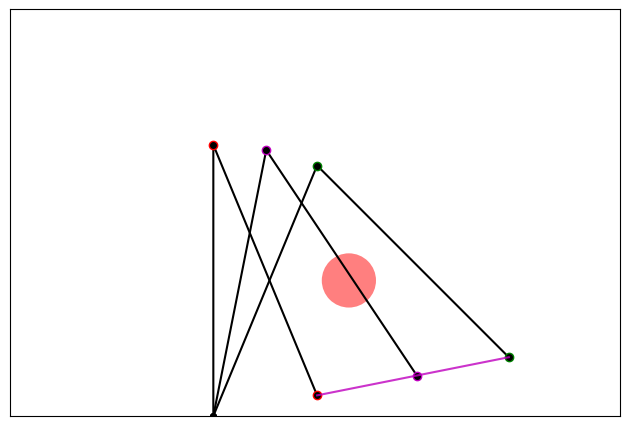

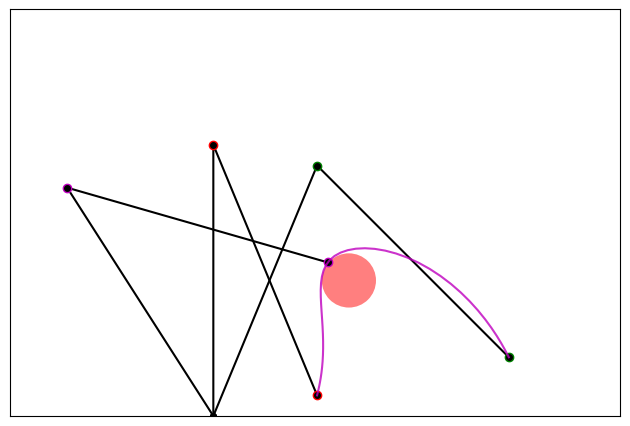

In [16]:
# 绘制笛卡尔空间中的机械臂轨迹对比
# 展示优化前后机械臂在任务空间中的表现

print("绘制笛卡尔空间轨迹对比...")
plotCartesianSpace(0)   # 绘制初始状态（优化前）
plotCartesianSpace(20)  # 绘制第20次迭代的状态（优化过程中）

绘制配置空间优化过程...


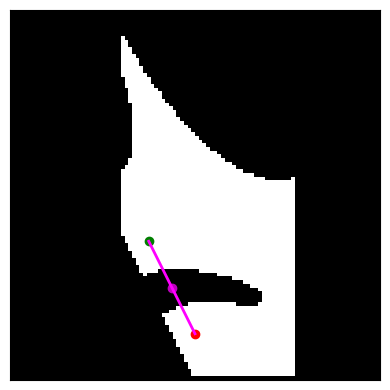

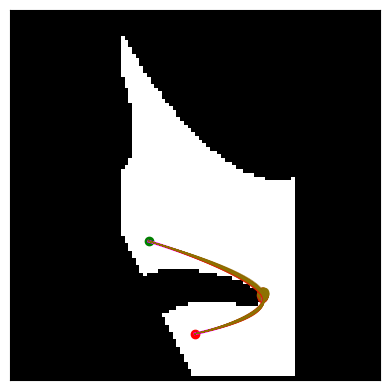

In [17]:
# 绘制配置空间中的轨迹优化过程
# 展示在关节角度空间中优化算法的搜索过程和收敛情况

print("绘制配置空间优化过程...")
plotCSpace(0)   # 绘制初始状态（优化前）
plotCSpace(20)  # 绘制第20次迭代的状态（显示种群分布和最优轨迹）

绘制优化空间搜索过程...


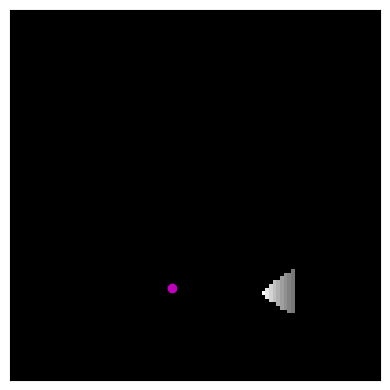

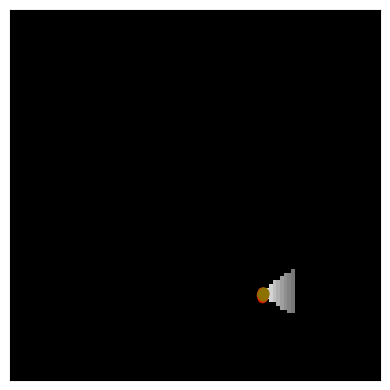

In [18]:
# 绘制优化空间的搜索过程
# 展示优化算法如何在途径点空间中搜索最优解

print("绘制优化空间搜索过程...")
plotOptSpace(0)   # 绘制初始状态（显示优化潜力地图）
plotOptSpace(20)  # 绘制第20次迭代的状态（显示候选解分布和搜索策略）

## 实验总结

本示例演示了如何使用VPSTO（Via-point-based Stochastic Trajectory Optimization）算法为2D机械臂生成避障轨迹。

### 主要组件：

1. **机械臂模型 (Manipulator)**：
   - 2自由度平面机械臂
   - 两段等长链接（长度均为1）
   - 关节角度限制：q1∈[0,π], q2∈[-π,0]

2. **碰撞环境 (CollisionEnvironment)**：
   - 圆形障碍物（半径0.1，中心在(0.5, 0.5)）
   - 工作空间边界限制
   - 高效的碰撞检测算法

3. **轨迹优化 (VPSTO)**：
   - 基于途径点的随机轨迹优化
   - 多目标损失函数：最小化时间 + 约束违反惩罚
   - 进化算法搜索最优途径点

### 可视化内容：

- **笛卡尔空间**：显示机械臂在任务空间中的实际运动轨迹
- **配置空间**：显示关节角度空间中的轨迹和优化过程
- **优化空间**：显示不同途径点的优化潜力和搜索策略

### 算法特点：

- 快速收敛：通过智能采样快速找到可行轨迹
- 约束满足：同时处理关节限制、碰撞避免和边界约束
- 时间最优：在满足约束的前提下最小化执行时间